In [2]:
%pip install pandas numpy matplotlib scikit-learn

You should consider upgrading via the 'c:\Users\yushi\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dataframe_image as dfi
import os

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
    ConfusionMatrixDisplay
)

In [2]:
# Load the dataset
df = pd.read_csv("../data/final_dataset.csv")



print("Shape:", df.shape)
display(df.head())
display(df.dtypes)

Shape: (196943, 23)


,date,station,TMAX,state,id,elevation,disasters_count,heat_related_disaster_count,heat_related_area_count,heat_related_any,...,p_unemp,p_nohsdp,p_uninsur,p_imperv,p_treec,p_age65,p_asthma,overall_score,hhb_score,pop_state_sum
0,2020-01-01,GHCND:USW00013876,56.0,AL,GHCND:USW00013876,187.7,0.0,0.0,0.0,0.0,...,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0
1,2020-01-02,GHCND:USW00013876,70.0,AL,GHCND:USW00013876,187.7,0.0,0.0,0.0,0.0,...,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0
2,2020-01-03,GHCND:USW00013876,65.0,AL,GHCND:USW00013876,187.7,0.0,0.0,0.0,0.0,...,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0
3,2020-01-04,GHCND:USW00013876,57.0,AL,GHCND:USW00013876,187.7,0.0,0.0,0.0,0.0,...,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0
4,2020-01-05,GHCND:USW00013876,57.0,AL,GHCND:USW00013876,187.7,0.0,0.0,0.0,0.0,...,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0


date                               object
station                            object
TMAX                              float64
state                              object
id                                 object
elevation                         float64
disasters_count                   float64
heat_related_disaster_count       float64
heat_related_area_count           float64
heat_related_any                  float64
heat_related_counties_affected    float64
state_fips                          int64
p_pov                             float64
p_unemp                           float64
p_nohsdp                          float64
p_uninsur                         float64
p_imperv                          float64
p_treec                           float64
p_age65                           float64
p_asthma                          float64
overall_score                     float64
hhb_score                         float64
pop_state_sum                     float64
dtype: object

In [3]:
# Basic data inspection
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_values": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique()
}).sort_values(by=["missing_percent", "unique_values"], ascending=[False, True])

display(summary)

,dtype,missing_values,missing_percent,unique_values
heat_related_any,float64,0,0.0,2
heat_related_disaster_count,float64,0,0.0,6
disasters_count,float64,0,0.0,8
state,object,0,0.0,40
state_fips,int64,0,0.0,40
p_pov,float64,0,0.0,40
p_unemp,float64,0,0.0,40
p_nohsdp,float64,0,0.0,40
p_uninsur,float64,0,0.0,40
p_imperv,float64,0,0.0,40


In [4]:
# Make a working copy and engineer date-based features
data = df.copy()

# Convert date to datetime
data["date"] = pd.to_datetime(data["date"])

# Create useful date features
data["year"] = data["date"].dt.year
data["month"] = data["date"].dt.month
data["dayofyear"] = data["date"].dt.dayofyear
data["dayofweek"] = data["date"].dt.dayofweek

# Columns that leak target information or are duplicates / less useful for this model
leakage_columns = [
    "heat_related_any",                 # target
    "heat_related_disaster_count",      # leaks heat event info
    "heat_related_area_count",          # leaks heat event info
    "heat_related_counties_affected",   # leaks heat event info
    "disasters_count"                   # highly related event count
]

duplicate_or_redundant_columns = [
    "date",       # replaced by engineered date features
    "id",         # duplicate of station in this dataset
    "state_fips"  # redundant with state
]

X = data.drop(columns=leakage_columns + duplicate_or_redundant_columns)
y = data[target].astype(int)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())
display(y.head())

NameError: name 'target' is not defined

In [ ]:
# Before-transformation snapshot
print("Before transformation snapshot:")
dfi.export(
    X.head(10), 
    "../../website/resources/img/tables/regression_raw_table.png",
    table_conversion="chrome",
    max_cols = 20
)
display(X.head(10))

Before transformation snapshot:


,station,TMAX,state,elevation,p_pov,p_unemp,p_nohsdp,p_uninsur,p_imperv,p_treec,p_age65,p_asthma,overall_score,hhb_score,pop_state_sum,year,month,dayofyear,dayofweek
0,GHCND:USW00013876,56.0,AL,187.7,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,1,2
1,GHCND:USW00013876,70.0,AL,187.7,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,2,3
2,GHCND:USW00013876,65.0,AL,187.7,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,3,4
3,GHCND:USW00013876,57.0,AL,187.7,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,4,5
4,GHCND:USW00013876,57.0,AL,187.7,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,5,6
5,GHCND:USW00013876,66.0,AL,187.7,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,6,0
6,GHCND:USW00013876,58.0,AL,187.7,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,7,1
7,GHCND:USW00013876,63.0,AL,187.7,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,8,2
8,GHCND:USW00013876,64.0,AL,187.7,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,9,3
9,GHCND:USW00013876,69.0,AL,187.7,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,10,4


In [9]:
# Stratified split: train / validation / test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.1765,   # makes ~15% validation out of full data
    random_state=42,
    stratify=y_train_full
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

print("\nTarget distribution:")
print("Train:", y_train.mean().round(6))
print("Validation:", y_val.mean().round(6))
print("Test:", y_test.mean().round(6))

Train shape: (137854, 19)
Validation shape: (29547, 19)
Test shape: (29542, 19)

Target distribution:
Train: 0.005905
Validation: 0.005889
Test: 0.00589


In [10]:
# Separate numerical and categorical columns
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['station', 'state']
Numeric columns: ['TMAX', 'elevation', 'p_pov', 'p_unemp', 'p_nohsdp', 'p_uninsur', 'p_imperv', 'p_treec', 'p_age65', 'p_asthma', 'overall_score', 'hhb_score', 'pop_state_sum', 'year', 'month', 'dayofyear', 'dayofweek']


In [11]:
# Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [ ]:
# Show before-and-after transformation snapshots
preprocessor.fit(X_train)

X_train_sample_raw = X_train.iloc[:5].copy()
X_train_sample_transformed = preprocessor.transform(X_train.iloc[:5])

feature_names = preprocessor.get_feature_names_out()

if hasattr(X_train_sample_transformed, "toarray"):
    X_train_sample_transformed = X_train_sample_transformed.toarray()

transformed_preview = pd.DataFrame(
    X_train_sample_transformed,
    columns=feature_names
)

print("Before transformation:")
display(X_train_sample_raw)
dfi.export(
    X_train_sample_raw, 
    "../../website/resources/img/tables/regression_raw_train_table.png",
    table_conversion="chrome",
    max_cols = 20
)

print("After transformation:")
display(transformed_preview.iloc[:, :20])  # show first 20 transformed columns only
dfi.export(
    transformed_preview.iloc[:, :20], 
    "../../website/resources/img/tables/regression_clean_table.png",
    table_conversion="chrome",
    max_cols = 20
)

print("Transformed training shape:", preprocessor.transform(X_train).shape)

Before transformation:


,station,TMAX,state,elevation,p_pov,p_unemp,p_nohsdp,p_uninsur,p_imperv,p_treec,p_age65,p_asthma,overall_score,hhb_score,pop_state_sum,year,month,dayofyear,dayofweek
112353,GHCND:USS0019K04S,41.0,NV,2401.8,22.726597,5.827957,14.143916,11.050751,40.509478,1.739495,15.463728,9.990376,0.694033,0.862394,2701260.0,2021,3,76,2
2087,GHCND:USC00031935,74.0,AR,530.4,28.227864,5.217266,12.941613,8.219707,7.857303,40.235269,16.908594,10.053575,0.552025,0.460649,2921346.0,2020,3,88,5
93479,GHCND:USS0013B22S,64.0,MT,1447.8,22.413104,4.212877,6.540941,9.053521,6.198811,15.769577,18.433988,10.400429,0.524548,0.697991,1014237.0,2024,6,180,4
88990,GHCND:USS0014A14S,69.0,MT,1534.7,22.413104,4.212877,6.540941,9.053521,6.198811,15.769577,18.433988,10.400429,0.524548,0.697991,1014237.0,2022,9,268,6
28321,GHCND:USC00186350,74.0,DC,15.2,19.960861,6.807317,8.950454,1.709962,50.756229,20.418148,12.211771,11.254879,0.507248,0.424856,601715.0,2023,10,286,4


After transformation:


,num__TMAX,num__elevation,num__p_pov,num__p_unemp,num__p_nohsdp,num__p_uninsur,num__p_imperv,num__p_treec,num__p_age65,num__p_asthma,num__overall_score,num__hhb_score,num__pop_state_sum,num__year,num__month,num__dayofyear,num__dayofweek,cat__station_GHCND:USC00020678,cat__station_GHCND:USC00031935,cat__station_GHCND:USC00057033
0,-0.882452,1.161066,0.640023,1.047138,1.497912,1.125911,1.775486,-1.236248,-0.127470,-0.680817,2.149259,0.947583,-0.406161,-0.699304,-1.019429,-1.014841,-0.497301,0.0,0.0,0.0
1,0.712991,-0.582141,1.896512,0.460941,1.101017,0.089039,-1.081690,1.111377,0.552394,-0.587603,0.307356,-0.362651,-0.367980,-1.404455,-1.019429,-0.901087,1.002742,0.0,1.0,0.0
2,0.229523,0.272416,0.568421,-0.503163,-1.011923,0.394424,-1.226814,-0.380638,1.270149,-0.076006,-0.049028,0.411405,-0.698830,1.416149,-0.149778,-0.028975,0.502728,0.0,0.0,0.0
3,0.471257,0.353364,0.568421,-0.503163,-1.011923,0.394424,-1.226814,-0.380638,1.270149,-0.076006,-0.049028,0.411405,-0.698830,0.005847,0.719872,0.805219,1.502757,0.0,0.0,0.0
4,0.712991,-1.062049,0.008329,1.987217,-0.216513,-2.295161,2.672111,-0.097150,-1.657638,1.184275,-0.273412,-0.479384,-0.770395,0.710998,1.009756,0.975849,0.502728,0.0,0.0,0.0


Transformed training shape: (137854, 169)


In [13]:
# Helper function to evaluate a classifier
def evaluate_model(y_true, y_pred, y_proba):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba)
    }
    return pd.DataFrame(metrics, index=["Score"]).T

In [14]:
# Baseline logistic regression model
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        solver="lbfgs",
        class_weight="balanced",
        random_state=42
    ))
])

baseline_model.fit(X_train, y_train)

val_proba_baseline = baseline_model.predict_proba(X_val)[:, 1]
val_pred_baseline = (val_proba_baseline >= 0.5).astype(int)

print("Baseline validation metrics:")
display(evaluate_model(y_val, val_pred_baseline, val_proba_baseline))

print("Baseline classification report:")
print(classification_report(y_val, val_pred_baseline, digits=4))

Baseline validation metrics:


,Score
Accuracy,0.692896
Precision,0.014192
Recall,0.747126
F1-score,0.027855
ROC-AUC,0.781214


Baseline classification report:
              precision    recall  f1-score   support

           0     0.9978    0.6926    0.8176     29373
           1     0.0142    0.7471    0.0279       174

    accuracy                         0.6929     29547
   macro avg     0.5060    0.7199    0.4227     29547
weighted avg     0.9920    0.6929    0.8130     29547



In [15]:
# Hyperparameter tuning on validation set
# Using a compact search because the dataset is large
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "class_weight": [None, "balanced"]
}

tuning_results = []

for params in ParameterGrid(param_grid):
    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            solver="lbfgs",
            C=params["C"],
            class_weight=params["class_weight"],
            random_state=42
        ))
    ])
    
    model.fit(X_train, y_train)
    
    val_proba = model.predict_proba(X_val)[:, 1]
    val_pred = (val_proba >= 0.5).astype(int)
    
    tuning_results.append({
        "C": params["C"],
        "class_weight": params["class_weight"],
        "accuracy": accuracy_score(y_val, val_pred),
        "precision": precision_score(y_val, val_pred, zero_division=0),
        "recall": recall_score(y_val, val_pred, zero_division=0),
        "f1": f1_score(y_val, val_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_val, val_proba)
    })

tuning_results_df = pd.DataFrame(tuning_results).sort_values(
    by=["f1", "roc_auc"], ascending=False
)

display(tuning_results_df)

best_params = tuning_results_df.iloc[0][["C", "class_weight"]].to_dict()
print("Best hyperparameters:", best_params)

,C,class_weight,accuracy,precision,recall,f1,roc_auc
1,0.01,balanced,0.698819,0.014793,0.764368,0.029023,0.790971
3,0.10,balanced,0.693742,0.014231,0.747126,0.027930,0.782886
5,1.00,balanced,0.692896,0.014192,0.747126,0.027855,0.781214
7,10.00,balanced,0.692084,0.014049,0.741379,0.027576,0.780974
2,0.10,None,0.994111,0.000000,0.000000,0.000000,0.801093
4,1.00,None,0.994111,0.000000,0.000000,0.000000,0.800904
6,10.00,None,0.994111,0.000000,0.000000,0.000000,0.800580
0,0.01,None,0.994111,0.000000,0.000000,0.000000,0.794316


Best hyperparameters: {'C': 0.01, 'class_weight': 'balanced'}


In [16]:
# Train best model on training split only, then tune threshold on validation set
best_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        solver="lbfgs",
        C=float(best_params["C"]),
        class_weight=best_params["class_weight"],
        random_state=42
    ))
])

best_model.fit(X_train, y_train)

val_proba_best = best_model.predict_proba(X_val)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_val, val_proba_best)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-12)

best_threshold_index = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_index]

threshold_results = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1],
    "f1": f1_scores
}).sort_values(by="f1", ascending=False)

print("Best threshold based on validation F1:", round(best_threshold, 4))
display(threshold_results.head(10))

Best threshold based on validation F1: 0.8269


,threshold,precision,recall,f1
28904,0.826907,0.060653,0.224138,0.095471
28903,0.826899,0.060559,0.224138,0.095355
28902,0.826829,0.060465,0.224138,0.095238
28901,0.826753,0.060372,0.224138,0.095122
28900,0.826659,0.060278,0.224138,0.095006
28899,0.826457,0.060185,0.224138,0.094891
28898,0.826454,0.060092,0.224138,0.094775
28897,0.826453,0.060000,0.224138,0.094660
28896,0.826418,0.059908,0.224138,0.094545
28895,0.826293,0.059816,0.224138,0.094431


In [17]:
# Retrain final model on train + validation data using best hyperparameters
X_train_final = pd.concat([X_train, X_val], axis=0)
y_train_final = pd.concat([y_train, y_val], axis=0)

final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        solver="lbfgs",
        C=float(best_params["C"]),
        class_weight=best_params["class_weight"],
        random_state=42
    ))
])

final_model.fit(X_train_final, y_train_final)

test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_threshold).astype(int)

print("Final test metrics:")
display(evaluate_model(y_test, test_pred, test_proba))

print("Final classification report:")
print(classification_report(y_test, test_pred, digits=4))

print("Confusion Matrix:")
print(confusion_matrix(y_test, test_pred))

Final test metrics:


,Score
Accuracy,0.975188
Precision,0.044046
Recall,0.155172
F1-score,0.068615
ROC-AUC,0.789545


Final classification report:
              precision    recall  f1-score   support

           0     0.9949    0.9800    0.9874     29368
           1     0.0440    0.1552    0.0686       174

    accuracy                         0.9752     29542
   macro avg     0.5195    0.5676    0.5280     29542
weighted avg     0.9893    0.9752    0.9820     29542

Confusion Matrix:
[[28782   586]
 [  147    27]]


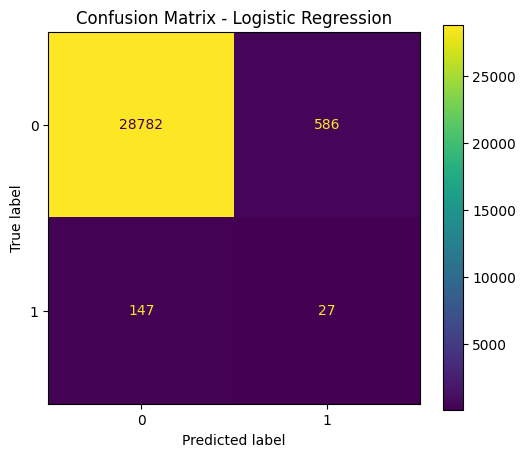

In [ ]:
# Confusion matrix plot
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, ax=ax)
plt.title("Confusion Matrix - Logistic Regression")
plt.savefig("../../website/resources/img/plots/regression_confusion_matrix.png")
plt.show()

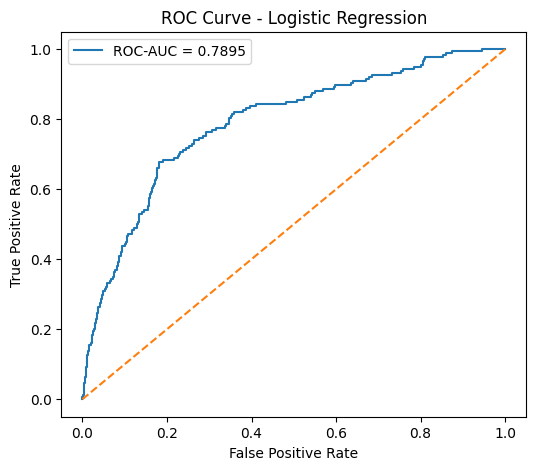

In [ ]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, test_proba)
roc_auc = roc_auc_score(y_test, test_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.savefig("../../website/resources/img/plots/regression_roc_curve.png")
plt.show()

In [20]:
# Interpret model coefficients
final_preprocessor = final_model.named_steps["preprocessor"]
final_lr = final_model.named_steps["model"]

feature_names = final_preprocessor.get_feature_names_out()
coefficients = final_lr.coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "odds_ratio": np.exp(coefficients)
})

top_positive = coef_df.sort_values(by="coefficient", ascending=False).head(15)
top_negative = coef_df.sort_values(by="coefficient", ascending=True).head(15)

print("Top positive predictors of heat-related events:")
display(top_positive)

print("Top negative predictors of heat-related events:")
display(top_negative)

Top positive predictors of heat-related events:


,feature,coefficient,odds_ratio
165,cat__state_WA,1.484462,4.412592
0,num__TMAX,0.878198,2.406558
10,num__overall_score,0.681109,1.976068
105,cat__station_GHCND:USW00014735,0.592622,1.808725
155,cat__state_NY,0.592622,1.808725
148,cat__state_MT,0.568762,1.766080
1,num__elevation,0.512576,1.669586
102,cat__station_GHCND:USW00013957,0.441988,1.555798
141,cat__state_LA,0.441988,1.555798
152,cat__state_NJ,0.405549,1.500126


Top negative predictors of heat-related events:


,feature,coefficient,odds_ratio
166,cat__state_WI,-0.773366,0.461457
139,cat__state_IL,-0.624763,0.535388
143,cat__state_MD,-0.542551,0.581264
167,cat__state_WV,-0.513689,0.598285
97,cat__station_GHCND:USW00003872,-0.513689,0.598285
2,num__p_pov,-0.512553,0.598964
145,cat__state_MI,-0.500789,0.606052
22,cat__station_GHCND:USC00117457,-0.453643,0.635309
134,cat__state_DC,-0.432996,0.648563
73,cat__station_GHCND:USS0012M26S,-0.324516,0.722877


Before training the logistic regression model, the dataset was carefully preprocessed so it matched the model’s requirements. The target variable was heat_related_any, which is a binary outcome, making logistic regression an appropriate choice. Several columns were removed because they would cause target leakage, including heat_related_disaster_count, heat_related_area_count, heat_related_counties_affected, and disasters_count, since these variables already contain information closely tied to the outcome being predicted. The original date column was converted into more useful numerical features such as year, month, dayofyear, and dayofweek, while redundant columns like id and state_fips were excluded. After preprocessing, the feature matrix contained 19 input variables. The data was then split using stratified sampling into training, validation, and test sets so that the very small positive class rate remained consistent across all sets. Because logistic regression requires numeric input, the categorical features station and state were one-hot encoded, numerical features were imputed with the median if needed and scaled using StandardScaler, and the final transformed training data expanded to 169 features.

The model results show both the strengths and limitations of logistic regression on this highly imbalanced dataset. The baseline model with class_weight="balanced" achieved a validation ROC-AUC of 0.7812, which suggested the model could separate the classes reasonably well, but its precision was extremely low because positive cases were rare. After tuning, the best hyperparameters were C = 0.01 with class_weight = "balanced", and the classification threshold was adjusted to 0.8269 to improve the F1-score. On the final test set, the model achieved an accuracy of 0.9752, precision of 0.0440, recall of 0.1552, F1-score of 0.0686, and ROC-AUC of 0.7895. The confusion matrix showed 28,782 true negatives, 586 false positives, 147 false negatives, and 27 true positives. Although the accuracy appears high, this is mainly because most observations belong to the negative class, so metrics like recall, F1-score, and ROC-AUC provide a more meaningful evaluation. Overall, the model was moderately effective at distinguishing heat-related events, but the low precision and recall indicate that predicting rare events in this dataset remains challenging.